# RAGWire in Practice — Providers and Cookbooks

Progressive journey:
- Swap providers with a single config change
- Use Qdrant Cloud with MMR retrieval

## 1. Setup

In [1]:
from dotenv import load_dotenv
load_dotenv()

from ragwire import RAGWire, setup_logging
import ragwire

logger = setup_logging(log_level="INFO")
print(ragwire.__version__)

c:\Users\laxmi\anaconda3\envs\ml\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.3.0) or chardet (7.1.0)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


1.2.7


## 2. RAGWire with All Providers

Switch providers by changing the config file. All agents share the same tools.

| Config | Embedding | LLM |
|---|---|---|
| `config_ollama.yaml` | `qwen3-embedding:0.6b` (Ollama) | `qwen3.5:27b` (Ollama) |
| `config_gemini.yaml` | `gemini-embedding-001` (Google) | `gemini-3.1-flash-lite-preview` (Google) |
| `config_openai.yaml` | `text-embedding-3-small` (OpenAI) | `gpt-5.4-nano` (OpenAI) |
| `config_groq.yaml` | `all-MiniLM-L6-v2` (HuggingFace) | `qwen/qwen3-32b` (Groq) |

In [4]:
rag = RAGWire('config_ollama.yaml')

stats = rag.ingest_directory('../data/finance_data')

2026-04-11 12:52:28,129 - ragwire.core.pipeline - INFO - Loading configuration from config_ollama.yaml
2026-04-11 12:52:28,150 - ragwire.core.pipeline - INFO - Document loader initialized
2026-04-11 12:52:28,151 - ragwire.core.pipeline - INFO - Text splitter initialized (strategy=markdown, chunk_size=10000)
2026-04-11 12:52:28,161 - ragwire.core.pipeline - INFO - Embedding model initialized (provider=ollama)
2026-04-11 12:52:28,173 - ragwire.core.pipeline - INFO - Metadata extractor loaded from: finance_metadata.yaml
2026-04-11 12:52:28,173 - ragwire.core.pipeline - INFO - LLM initialized for metadata extraction (provider=ollama, model=qwen3.5:9b)
2026-04-11 12:52:28,184 - ragwire.vectorstores.qdrant_store - INFO - Connected to Qdrant at http://localhost:6333
2026-04-11 12:52:28,193 - ragwire.core.pipeline - INFO - Using existing collection: finance-rag-ollama
2026-04-11 12:52:30,181 - ragwire.core.pipeline - INFO - Vector store initialized
2026-04-11 12:52:30,182 - ragwire.core.pipeli

Ingesting:   0%|          | 0/6 [00:00<?, ?file/s]

2026-04-11 12:52:30,210 - ragwire.core.pipeline - INFO - Skipping (already ingested): ..\data\finance_data\amazon 10-k 2024.pdf
2026-04-11 12:52:30,255 - ragwire.core.pipeline - INFO - Skipping (already ingested): ..\data\finance_data\amazon 10k 2025.pdf
2026-04-11 12:52:30,286 - ragwire.core.pipeline - INFO - Skipping (already ingested): ..\data\finance_data\apple 10-k 2024.pdf
2026-04-11 12:52:30,318 - ragwire.core.pipeline - INFO - Skipping (already ingested): ..\data\finance_data\Apple_10k_2025.pdf


Ingesting:  67%|██████▋   | 4/6 [00:00<00:00, 30.26file/s]

2026-04-11 12:52:30,365 - ragwire.core.pipeline - INFO - Skipping (already ingested): ..\data\finance_data\GOOG-10-K-2025.pdf
2026-04-11 12:52:30,383 - ragwire.core.pipeline - INFO - Skipping (already ingested): ..\data\finance_data\google 10-k 2024.pdf


Ingesting: 100%|██████████| 6/6 [00:00<00:00, 30.39file/s]


2026-04-11 12:52:30,786 - ragwire.core.pipeline - INFO - Ingestion complete: 0/6 documents


### OpenAI

In [5]:
rag_openai = RAGWire('config_openai.yaml')

stats = rag_openai.ingest_directory('../data/finance_data')

2026-04-11 12:52:30,792 - ragwire.core.pipeline - INFO - Loading configuration from config_openai.yaml
2026-04-11 12:52:30,813 - ragwire.core.pipeline - INFO - Document loader initialized
2026-04-11 12:52:30,814 - ragwire.core.pipeline - INFO - Text splitter initialized (strategy=markdown, chunk_size=10000)
2026-04-11 12:52:33,202 - ragwire.core.pipeline - INFO - Embedding model initialized (provider=openai)
2026-04-11 12:52:33,216 - ragwire.core.pipeline - INFO - Metadata extractor loaded from: finance_metadata.yaml
2026-04-11 12:52:33,217 - ragwire.core.pipeline - INFO - LLM initialized for metadata extraction (provider=openai, model=gpt-5.4-nano)
2026-04-11 12:52:33,228 - ragwire.vectorstores.qdrant_store - INFO - Connected to Qdrant at http://localhost:6333
2026-04-11 12:52:33,234 - ragwire.core.pipeline - INFO - Using existing collection: finance-rag-openai
2026-04-11 12:52:35,833 - ragwire.core.pipeline - INFO - Vector store initialized
2026-04-11 12:52:35,834 - ragwire.core.pipe

Ingesting:   0%|          | 0/6 [00:00<?, ?file/s]

2026-04-11 12:52:35,861 - ragwire.core.pipeline - INFO - Skipping (already ingested): ..\data\finance_data\amazon 10-k 2024.pdf
2026-04-11 12:52:35,891 - ragwire.core.pipeline - INFO - Skipping (already ingested): ..\data\finance_data\amazon 10k 2025.pdf
2026-04-11 12:52:35,935 - ragwire.core.pipeline - INFO - Skipping (already ingested): ..\data\finance_data\apple 10-k 2024.pdf
2026-04-11 12:52:35,966 - ragwire.core.pipeline - INFO - Skipping (already ingested): ..\data\finance_data\Apple_10k_2025.pdf


Ingesting:  67%|██████▋   | 4/6 [00:00<00:00, 31.29file/s]

2026-04-11 12:52:35,984 - ragwire.core.pipeline - INFO - Skipping (already ingested): ..\data\finance_data\GOOG-10-K-2025.pdf
2026-04-11 12:52:36,012 - ragwire.core.pipeline - INFO - Skipping (already ingested): ..\data\finance_data\google 10-k 2024.pdf


Ingesting: 100%|██████████| 6/6 [00:00<00:00, 34.35file/s]


2026-04-11 12:52:36,394 - ragwire.core.pipeline - INFO - Ingestion complete: 0/6 documents


In [6]:
rag_openai.retrieve("what is apple revenue in 2025?")

2026-04-11 12:52:38,890 - ragwire.core.pipeline - INFO - Auto-extracted filters from query: {'company_name': 'apple inc.', 'fiscal_year': 2025}
2026-04-11 12:52:39,952 - ragwire.core.pipeline - INFO - Retrieved 5 documents for query: what is apple revenue in 2025?...


[Document(metadata={'source': '..\\data\\finance_data\\Apple_10k_2025.pdf', 'file_name': 'Apple_10k_2025.pdf', 'file_type': 'pdf', 'file_hash': '108590052c3ba5400c63660d787fe7ed4e43868292946d7a7facebe9ab7d1aab', 'chunk_id': '108590052c3ba5400c63660d787fe7ed4e43868292946d7a7facebe9ab7d1aab_17', 'chunk_hash': '6f8d154ee3123334dcf4f277a15aaf1d235ed46a0a4fa4a3adcf44b3ade8c2b6', 'chunk_index': 17, 'total_chunks': 35, 'created_at': '2026-04-10T19:51:08.962784+00:00', 'company_name': 'apple inc.', 'doc_type': '10-k', 'fiscal_year': 2025, 'fiscal_quarter': None, '_id': 'a67bd317-8ff5-49c9-803c-e789cd5f6764', '_collection_name': 'finance-rag-openai'}, page_content='Recently Adopted Accounting Pronouncements\n\nSegment Reporting\n\nBeginning  with  the  2025  annual  reporting  period,  the  Company  adopted  the  FASB’s  ASU  No.  2023-07,  Segment  Reporting  (Topic  280):  Improvements  to\nReportable Segment Disclosures (“ASU 2023-07”), which requires the Company to disclose segment expenses

### Groq

In [7]:
# !pip install langchain-huggingface

In [8]:
load_dotenv(override=True)

rag_groq = RAGWire('config_groq.yaml')

2026-04-11 12:52:39,966 - ragwire.core.pipeline - INFO - Loading configuration from config_groq.yaml
2026-04-11 12:52:39,989 - ragwire.core.pipeline - INFO - Document loader initialized
2026-04-11 12:52:39,990 - ragwire.core.pipeline - INFO - Text splitter initialized (strategy=markdown, chunk_size=10000)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


2026-04-11 12:52:44,701 - ragwire.core.pipeline - INFO - Embedding model initialized (provider=huggingface)
2026-04-11 12:52:45,044 - ragwire.core.pipeline - INFO - Metadata extractor loaded from: finance_metadata.yaml
2026-04-11 12:52:45,045 - ragwire.core.pipeline - INFO - LLM initialized for metadata extraction (provider=groq, model=qwen/qwen3-32b)
2026-04-11 12:52:45,056 - ragwire.vectorstores.qdrant_store - INFO - Connected to Qdrant at http://localhost:6333
2026-04-11 12:52:45,106 - ragwire.vectorstores.qdrant_store - INFO - Deleted collection: finance-rag-groq
2026-04-11 12:52:45,107 - ragwire.core.pipeline - INFO - Deleted existing collection for recreation: finance-rag-groq
2026-04-11 12:52:45,599 - ragwire.vectorstores.qdrant_store - INFO - Created collection 'finance-rag-groq' with hybrid search
2026-04-11 12:52:45,599 - ragwire.core.pipeline - INFO - Created new collection: finance-rag-groq
2026-04-11 12:52:45,912 - ragwire.core.pipeline - INFO - Vector store initialized
20

In [9]:
rag_groq.ingest_documents([r'..\data\finance_data\amazon 10-k 2024.pdf'])

2026-04-11 12:52:45,920 - ragwire.core.pipeline - INFO - Starting ingestion of 1 documents


Ingesting:   0%|          | 0/1 [00:00<?, ?file/s]

2026-04-11 12:53:14,182 - ragwire.core.pipeline - INFO - Processed ..\data\finance_data\amazon 10-k 2024.pdf: 39 chunks


Ingesting: 100%|██████████| 1/1 [00:28<00:00, 28.26s/file]


2026-04-11 12:53:16,029 - ragwire.core.pipeline - INFO - Ingestion complete: 1/1 documents


{'total': 1,
 'processed': 1,
 'skipped': 0,
 'failed': 0,
 'chunks_created': 39,
 'errors': []}

In [10]:
rag_groq.retrieve("what is amazon revenue in 2024?")

2026-04-11 12:53:16,889 - ragwire.core.pipeline - INFO - Auto-extracted filters from query: {'company_name': 'amazon.com inc.', 'fiscal_year': 2024}
2026-04-11 12:53:16,911 - ragwire.core.pipeline - INFO - Retrieved 5 documents for query: what is amazon revenue in 2024?...


[Document(metadata={'source': '..\\data\\finance_data\\amazon 10-k 2024.pdf', 'file_name': 'amazon 10-k 2024.pdf', 'file_type': 'pdf', 'file_hash': '5b582c59f1d1fa81d5112c9e0b9aa87afdbc9f42418daace257bc360e0f61ef7', 'chunk_id': '5b582c59f1d1fa81d5112c9e0b9aa87afdbc9f42418daace257bc360e0f61ef7_20', 'chunk_hash': 'bacb300a3e5f8fc231d631fe431c430f0f88f6296db5d295389f31aa60ac9a2b', 'chunk_index': 20, 'total_chunks': 39, 'created_at': '2026-04-11T07:23:13.944902+00:00', 'company_name': 'amazon.com inc.', 'doc_type': '10-k', 'fiscal_year': 2024, 'fiscal_quarter': None, '_id': 'ccdceb44-04aa-4410-a1c9-013795179b9c', '_collection_name': 'finance-rag-groq'}, page_content='We had previously increased the useful life of our servers from five years to six years effective January 1, 2024. The effect of this change for the year\n\nended December 31, 2024, based on servers that were included in “Property and equipment,\n\n41\n\n\x0cTable of Contents\n\nnet” as of December 31, 2023 and those acquired 

### Gemini

In [11]:
load_dotenv(override=True)

True

In [12]:
# import os
# os.getenv('GOOGLE_API_KEY')

In [13]:
rag_gemini = RAGWire('config_gemini.yaml')

2026-04-11 12:53:16,937 - ragwire.core.pipeline - INFO - Loading configuration from config_gemini.yaml
2026-04-11 12:53:16,959 - ragwire.core.pipeline - INFO - Document loader initialized
2026-04-11 12:53:16,959 - ragwire.core.pipeline - INFO - Text splitter initialized (strategy=markdown, chunk_size=10000)
2026-04-11 12:53:19,100 - ragwire.core.pipeline - INFO - Embedding model initialized (provider=google)
2026-04-11 12:53:19,105 - ragwire.core.pipeline - INFO - Metadata extractor loaded from: finance_metadata.yaml
2026-04-11 12:53:19,106 - ragwire.core.pipeline - INFO - LLM initialized for metadata extraction (provider=google, model=gemini-2.5-flash)
2026-04-11 12:53:19,117 - ragwire.vectorstores.qdrant_store - INFO - Connected to Qdrant at http://localhost:6333
2026-04-11 12:53:19,178 - ragwire.vectorstores.qdrant_store - INFO - Deleted collection: finance-rag-google
2026-04-11 12:53:19,178 - ragwire.core.pipeline - INFO - Deleted existing collection for recreation: finance-rag-goo

In [14]:
rag_gemini.ingest_documents([r'..\data\finance_data\amazon 10-k 2024.pdf'])

2026-04-11 12:53:20,713 - ragwire.core.pipeline - INFO - Starting ingestion of 1 documents


Ingesting:   0%|          | 0/1 [00:00<?, ?file/s]

2026-04-11 12:54:07,524 - ragwire.core.pipeline - INFO - Processed ..\data\finance_data\amazon 10-k 2024.pdf: 39 chunks


Ingesting: 100%|██████████| 1/1 [00:46<00:00, 46.81s/file]


2026-04-11 12:54:09,334 - ragwire.core.pipeline - INFO - Ingestion complete: 1/1 documents


{'total': 1,
 'processed': 1,
 'skipped': 0,
 'failed': 0,
 'chunks_created': 39,
 'errors': []}

In [15]:
rag_gemini.retrieve("what is amazon revenue in 2024?")

2026-04-11 12:54:12,213 - ragwire.core.pipeline - INFO - Auto-extracted filters from query: {'company_name': 'amazon.com inc.', 'fiscal_year': 2024}
2026-04-11 12:54:12,675 - ragwire.core.pipeline - INFO - Retrieved 5 documents for query: what is amazon revenue in 2024?...


[Document(metadata={'source': '..\\data\\finance_data\\amazon 10-k 2024.pdf', 'file_name': 'amazon 10-k 2024.pdf', 'file_type': 'pdf', 'file_hash': '5b582c59f1d1fa81d5112c9e0b9aa87afdbc9f42418daace257bc360e0f61ef7', 'chunk_id': '5b582c59f1d1fa81d5112c9e0b9aa87afdbc9f42418daace257bc360e0f61ef7_20', 'chunk_hash': 'bacb300a3e5f8fc231d631fe431c430f0f88f6296db5d295389f31aa60ac9a2b', 'chunk_index': 20, 'total_chunks': 39, 'created_at': '2026-04-11T07:23:53.323846+00:00', 'company_name': 'amazon.com inc.', 'doc_type': '10-k', 'fiscal_year': 2024, 'fiscal_quarter': None, '_id': '57efe88b-38d5-4e77-8d4f-9022e0a0938a', '_collection_name': 'finance-rag-google'}, page_content='We had previously increased the useful life of our servers from five years to six years effective January 1, 2024. The effect of this change for the year\n\nended December 31, 2024, based on servers that were included in “Property and equipment,\n\n41\n\n\x0cTable of Contents\n\nnet” as of December 31, 2023 and those acquire

## 3. Cookbooks — Qdrant Cloud + MMR Retrieval

**Model:** `gemini-3.1-flash-lite-preview` (Google) · **Embedding:** `gemini-embedding-001` (Google) · **Vector Store:** Qdrant Cloud

Two things change vs local setup:
- `vectorstore.url` points to your Qdrant Cloud cluster URL
- `retriever.search_type: mmr` reduces redundant chunks by maximising marginal relevance

Everything else — ingest, retrieve, agent — is identical.

In [2]:
load_dotenv(override=True)

rag_qdrant = RAGWire("config_gemini_qdrant.yaml")

2026-04-12 09:45:24,983 - ragwire.core.pipeline - INFO - Loading configuration from config_gemini_qdrant.yaml
2026-04-12 09:45:25,322 - ragwire.core.pipeline - INFO - Document loader initialized
2026-04-12 09:45:25,324 - ragwire.core.pipeline - INFO - Text splitter initialized (strategy=markdown, chunk_size=10000)
2026-04-12 09:45:26,763 - ragwire.core.pipeline - INFO - Embedding model initialized (provider=google)
2026-04-12 09:45:26,769 - ragwire.core.pipeline - INFO - Metadata extractor loaded from: finance_metadata.yaml
2026-04-12 09:45:26,769 - ragwire.core.pipeline - INFO - LLM initialized for metadata extraction (provider=google, model=gemini-2.5-flash)
2026-04-12 09:45:27,125 - ragwire.vectorstores.qdrant_store - INFO - Connected to Qdrant at https://a432d78b-1429-48dd-b910-31d2d5c8b296.sa-east-1-0.aws.cloud.qdrant.io:6333
2026-04-12 09:45:28,394 - ragwire.vectorstores.qdrant_store - INFO - Deleted collection: finance-rag-google-qdrant
2026-04-12 09:45:28,395 - ragwire.core.pip

In [ ]:
rag_qdrant.ingest_directory("../data/finance_data")

2026-04-12 09:45:31,139 - ragwire.core.pipeline - INFO - Found 6 file(s) in ../data/finance_data
2026-04-12 09:45:31,140 - ragwire.core.pipeline - INFO - Starting ingestion of 6 documents


Ingesting:   0%|          | 0/6 [00:00<?, ?file/s]

2026-04-12 09:46:18,371 - ragwire.core.pipeline - INFO - Processed ..\data\finance_data\amazon 10-k 2024.pdf: 39 chunks


Ingesting:  17%|█▋        | 1/6 [00:47<03:56, 47.23s/file]

2026-04-12 09:47:01,921 - ragwire.core.pipeline - INFO - Processed ..\data\finance_data\amazon 10k 2025.pdf: 38 chunks


...

2026-04-12 09:49:47,558 - ragwire.core.pipeline - INFO - Processed ..\data\finance_data\google 10-k 2024.pdf: 49 chunks


Ingesting: 100%|██████████| 6/6 [04:16<00:00, 42.74s/file]


2026-04-12 09:49:52,679 - ragwire.core.pipeline - INFO - Ingestion complete: 6/6 documents


{'total': 6,
 'processed': 6,
 'skipped': 0,
 'failed': 0,
 'chunks_created': 260,
 'errors': []}

: 

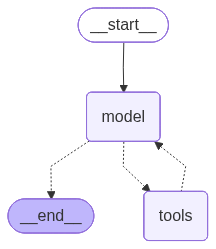

In [22]:
from langchain.agents import create_agent
from langchain.tools import tool
from langchain.messages import HumanMessage
from langchain_ollama import ChatOllama
from langgraph.checkpoint.memory import InMemorySaver
from langchain_google_genai import ChatGoogleGenerativeAI

@tool
def get_filter_context(query: str) -> str:
    """Get available metadata fields, stored values, and filter suggestions for a query.

    Call this before search_documents when the query involves a specific company,
    year, or document type. Skip for purely semantic queries.
    """
    return rag_qdrant.get_filter_context(query)

@tool
def search_documents(query: str, filters=None):
    """Search the document knowledge base for relevant information.

    Args:
        query: The search query
        filters: Optional metadata filters from get_filter_context.
    """

    results = rag_qdrant.retrieve(query=query, filters=filters)

    if not results:
        return "No relevant information is found!"
    else:
        return results 
    
# model = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite-preview")

agent = create_agent(
    model=ChatGoogleGenerativeAI(model="gemini-2.5-flash"),
    tools=[get_filter_context, search_documents],
    system_prompt=(
        "You are a helpful financial document assistant. "
        "For complex questions, break them down into simple sub-questions. "
        "Always use search_documents to retrieve information — never answer from general knowledge. "
        "Use get_filter_context before search_documents when the query involves specific metadata. "
        "Always cite the source document in your answer."
    ),
    checkpointer=InMemorySaver(),
)

agent



In [23]:
config = {"configurable": {"thread_id": "demo"}}

print("\nRAG Agent ready. Type 'quit' to exit.\n")

while True:
    question = input("You: ").strip()
    if question.lower() in ("quit", "exit", "q"):
        break
    if not question:
        continue
    response = agent.invoke(
        {"messages": [HumanMessage(question)]},
        config=config,
    )
    print(f"\nAgent: {response['messages'][-1].text}\n")


RAG Agent ready. Type 'quit' to exit.

2026-04-11 13:27:57,548 - ragwire.core.pipeline - INFO - Auto-extracted filters from query: {'company_name': 'apple inc.', 'fiscal_year': 2025}

Agent: I apologize, but I am unable to retrieve the revenue for Apple in 2025 at this time. I am encountering an internal error when trying to search for the document with the specified fiscal year. Please try again later.

2026-04-11 13:28:52,892 - ragwire.core.pipeline - INFO - Auto-extracted filters from query: {'company_name': 'apple inc.', 'fiscal_year': 2025}
2026-04-11 13:28:59,037 - ragwire.core.pipeline - INFO - Retrieved 5 documents for query: Apple revenue in 2025...

Agent: Apple's total net sales for 2025 were $416,161 million.

Source: Apple_10k_2025.pdf

2026-04-11 13:29:35,479 - ragwire.core.pipeline - INFO - Auto-extracted filters from query: {'company_name': 'alphabet inc.', 'fiscal_year': 2024}
2026-04-11 13:29:49,484 - ragwire.core.pipeline - INFO - Auto-extracted filters from query: 